### Architecture 
the same experiment 12 is again conducted with extra epochs to 30 instead of 10 and early stopping increase to 10 iteration instead of 5, But again, the validation converges after 3,4 epochs and then stay flat which means

<br>
<br>

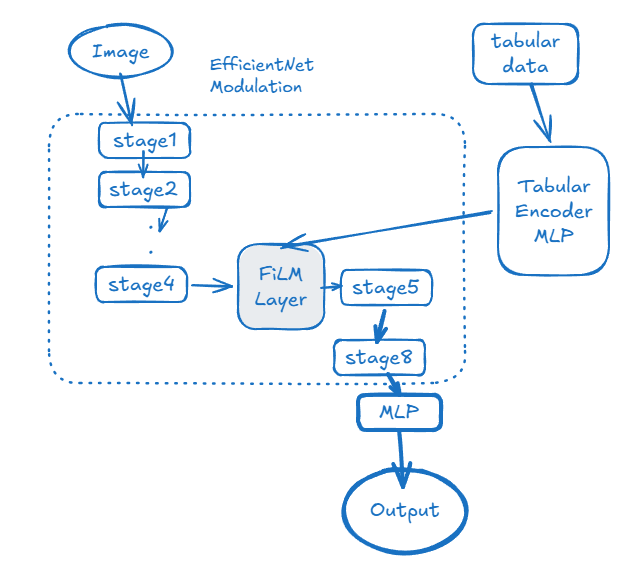



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [17]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_single_modulation_epoch30")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_single_modulation"
cfg["epochs"] = 30
cfg["patience"] = 10
cfg["seed"] = 423
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=4,                   # to update the backbone block
    apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 4th stage/block of EfficientNet
    use_bn_affine=False,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_single_modulation: Fold 1 ===
Epoch 1/30 | Fold 1 | Train[MSE]: RMSE=39.7309 | ValRMSE: 33.2031
Epoch 2/30 | Fold 1 | Train[MSE]: RMSE=30.0457 | ValRMSE: 26.5363
Epoch 3/30 | Fold 1 | Train[MSE]: RMSE=21.2999 | ValRMSE: 20.1560
Epoch 4/30 | Fold 1 | Train[MSE]: RMSE=17.7021 | ValRMSE: 20.6596
Epoch 5/30 | Fold 1 | Train[MSE]: RMSE=15.9795 | ValRMSE: 20.3879
Epoch 6/30 | Fold 1 | Train[MSE]: RMSE=14.2149 | ValRMSE: 21.0694
Epoch 7/30 | Fold 1 | Train[MSE]: RMSE=12.7034 | ValRMSE: 21.0041
Epoch 8/30 | Fold 1 | Train[MSE]: RMSE=11.2577 | ValRMSE: 21.0110
Epoch 9/30 | Fold 1 | Train[MSE]: RMSE=10.3418 | ValRMSE: 21.3560
Epoch 10/30 | Fold 1 | Train[MSE]: RMSE=9.4843 | ValRMSE: 21.3209
Epoch 11/30 | Fold 1 | Train[MSE]: RMSE=8.8957 | ValRMSE: 21.0874
Epoch 12/30 | Fold 1 | Train[MSE]: RMSE=8.1434 | ValRMSE: 21.3818
Epoch 13/30 | Fold 1 | Train[MSE]: RMSE=7.8060 | ValRMSE: 21.2514
Early stopping at epoch 13
Fold 1 best RMSE: 20.1560

=== exp12_film_fusio

In [19]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 20.1560 (n=1983)
Fold 2 OOF RMSE: 19.6044 (n=1983)
Fold 3 OOF RMSE: 20.0068 (n=1982)
Fold 4 OOF RMSE: 20.3634 (n=1982)
Fold 5 OOF RMSE: 20.4186 (n=1982)


### Train and Validation RMSE Curve

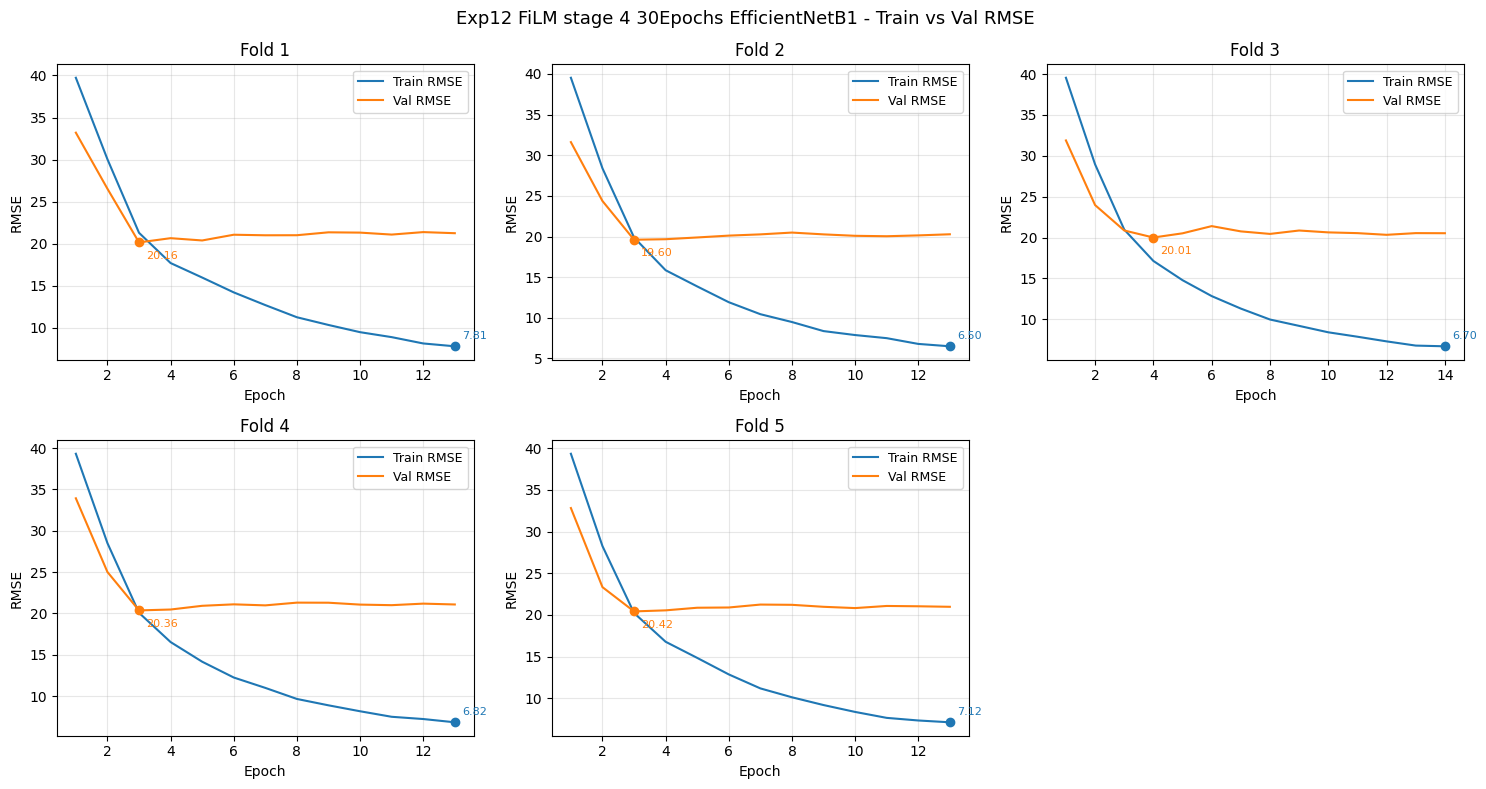

In [21]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM stage 4 30Epochs EfficientNetB1")

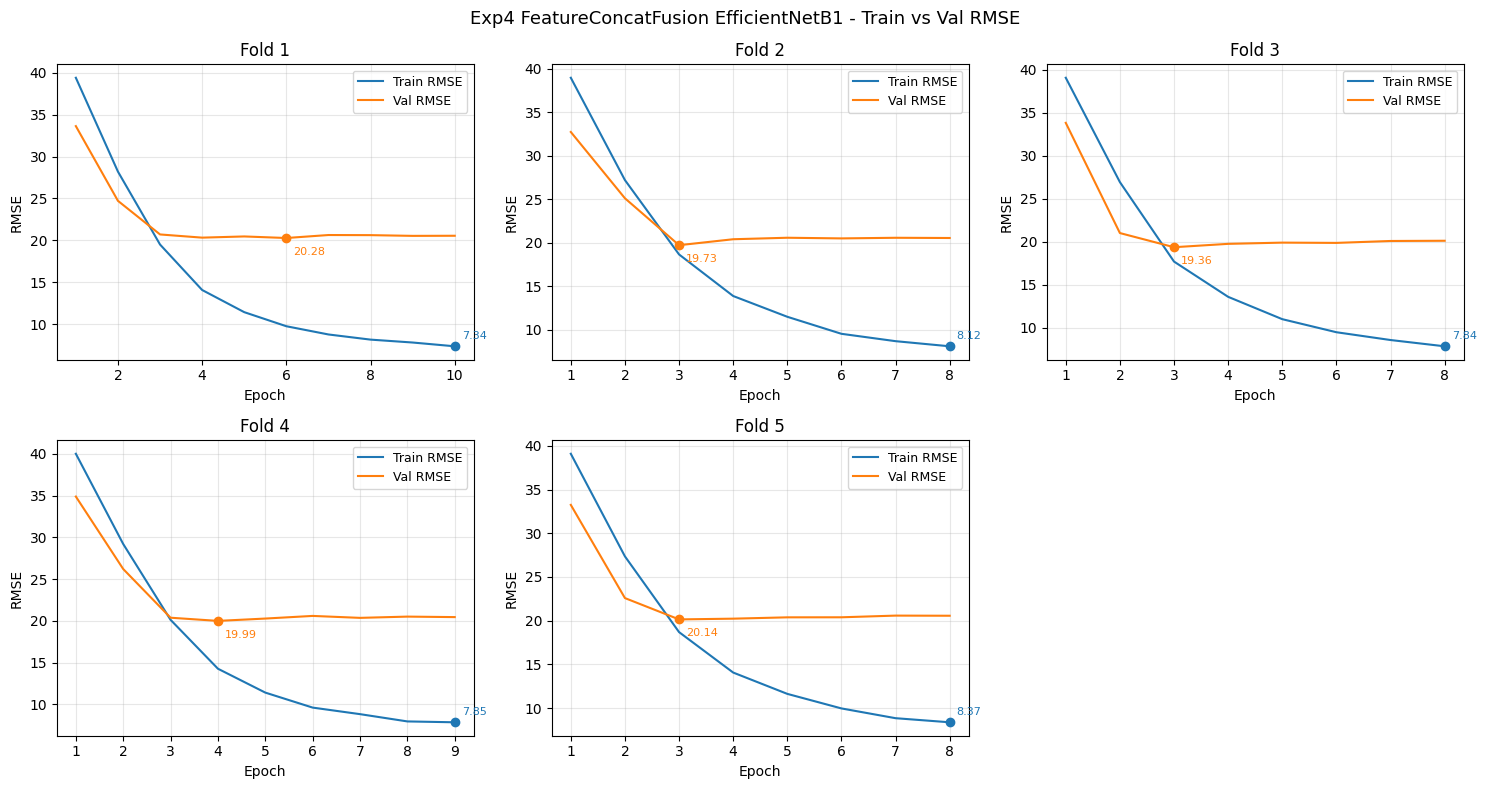

In [8]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

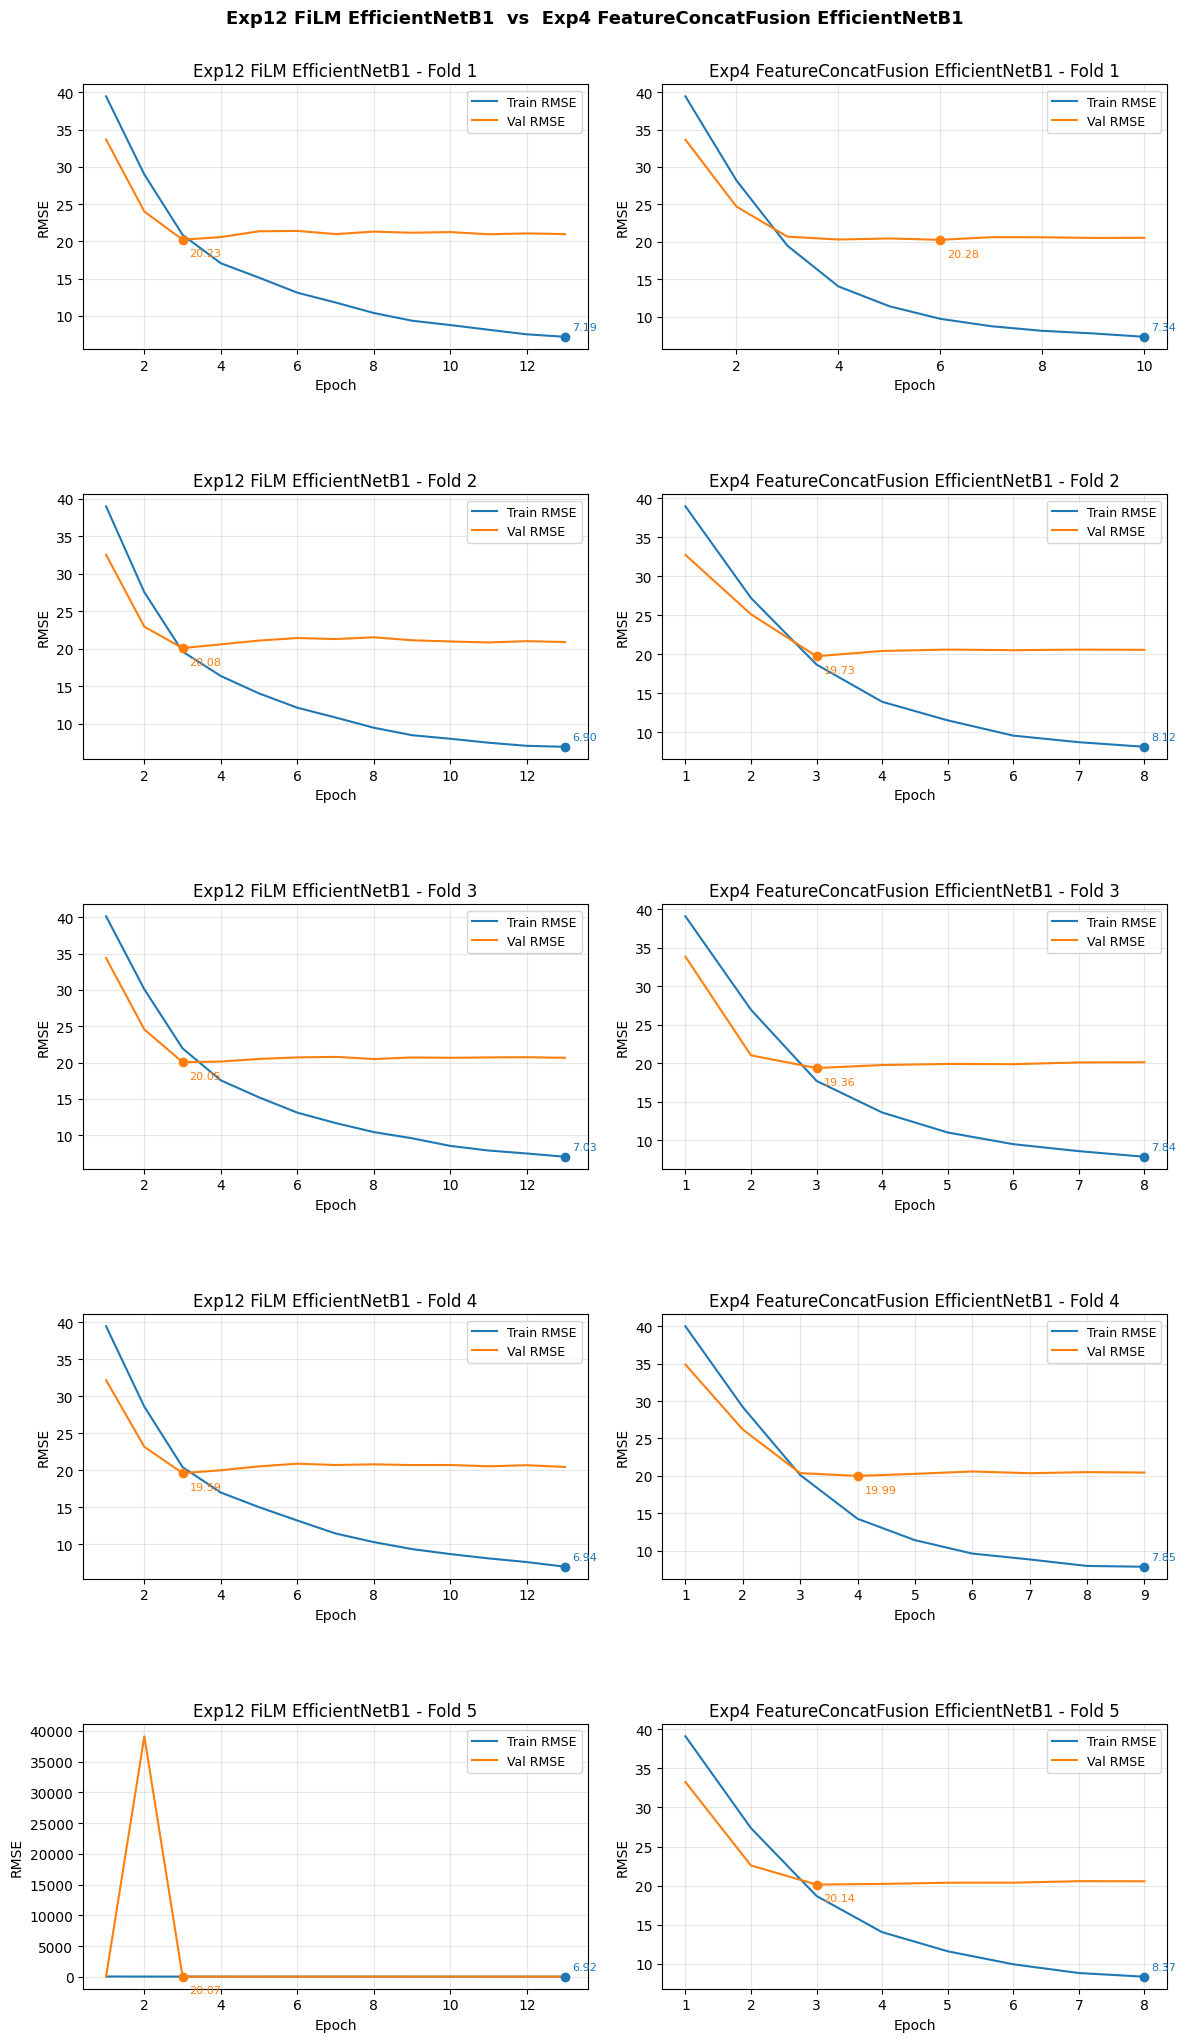

In [9]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [11]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,0254f54b148543442373d5aad45b2d1a,3,100,16.629601,83.370399
1,6dcb7396e06ee6a538522d2f67f017db,5,100,20.429964,79.570036
2,118ca1a5339f8d6f2794dfc7086ec46a,3,94,15.151953,78.848047
3,ec07599018885a44734a9ba27d306055,2,99,21.891249,77.108751
4,71fa4d85742ba547591ffc91736c1f29,2,100,23.397421,76.602579


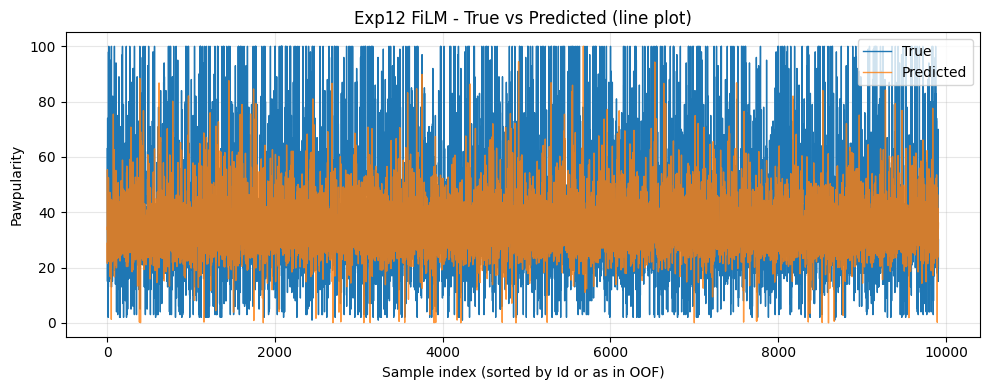

In [12]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM")





Exp12_FiLM_Eff_B1 Fusion OOF RMSE: 20.005929643737506
Exp4_FeatureConcat EffB1 Fusion OOF RMSE: 19.90331621767278
ΔRMSE (Exp4_FeatureConcat EffB1 Fusion - Exp12_FiLM_Eff_B1 Fusion): -0.10261342606472468


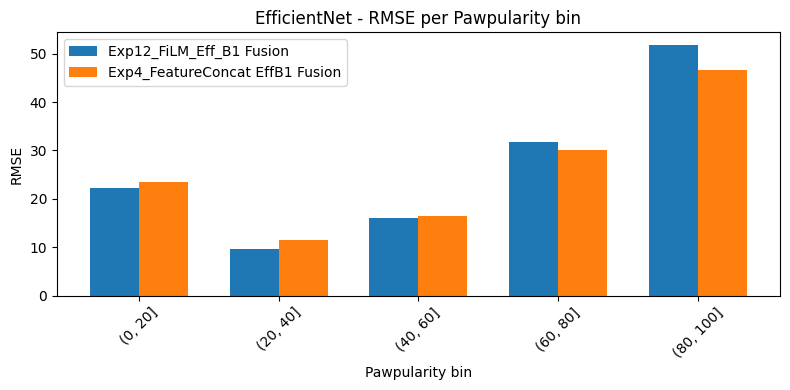

In [13]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12_FiLM_Eff_B1 Fusion",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

In [14]:
df_bins.head()

,bin,count,Exp12_FiLM_Eff_B1 Fusion_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,22.281599,23.561754,1.280155,Exp12_FiLM_Eff_B1 Fusion_better
1,"(20, 40]",5119,9.656663,11.605182,1.948518,Exp12_FiLM_Eff_B1 Fusion_better
2,"(40, 60]",2088,16.149989,16.538259,0.388271,Exp12_FiLM_Eff_B1 Fusion_better
3,"(60, 80]",727,31.825175,30.127592,-1.697583,Exp4_FeatureConcat EffB1 Fusion_better
4,"(80, 100]",561,51.801222,46.623998,-5.177224,Exp4_FeatureConcat EffB1 Fusion_better


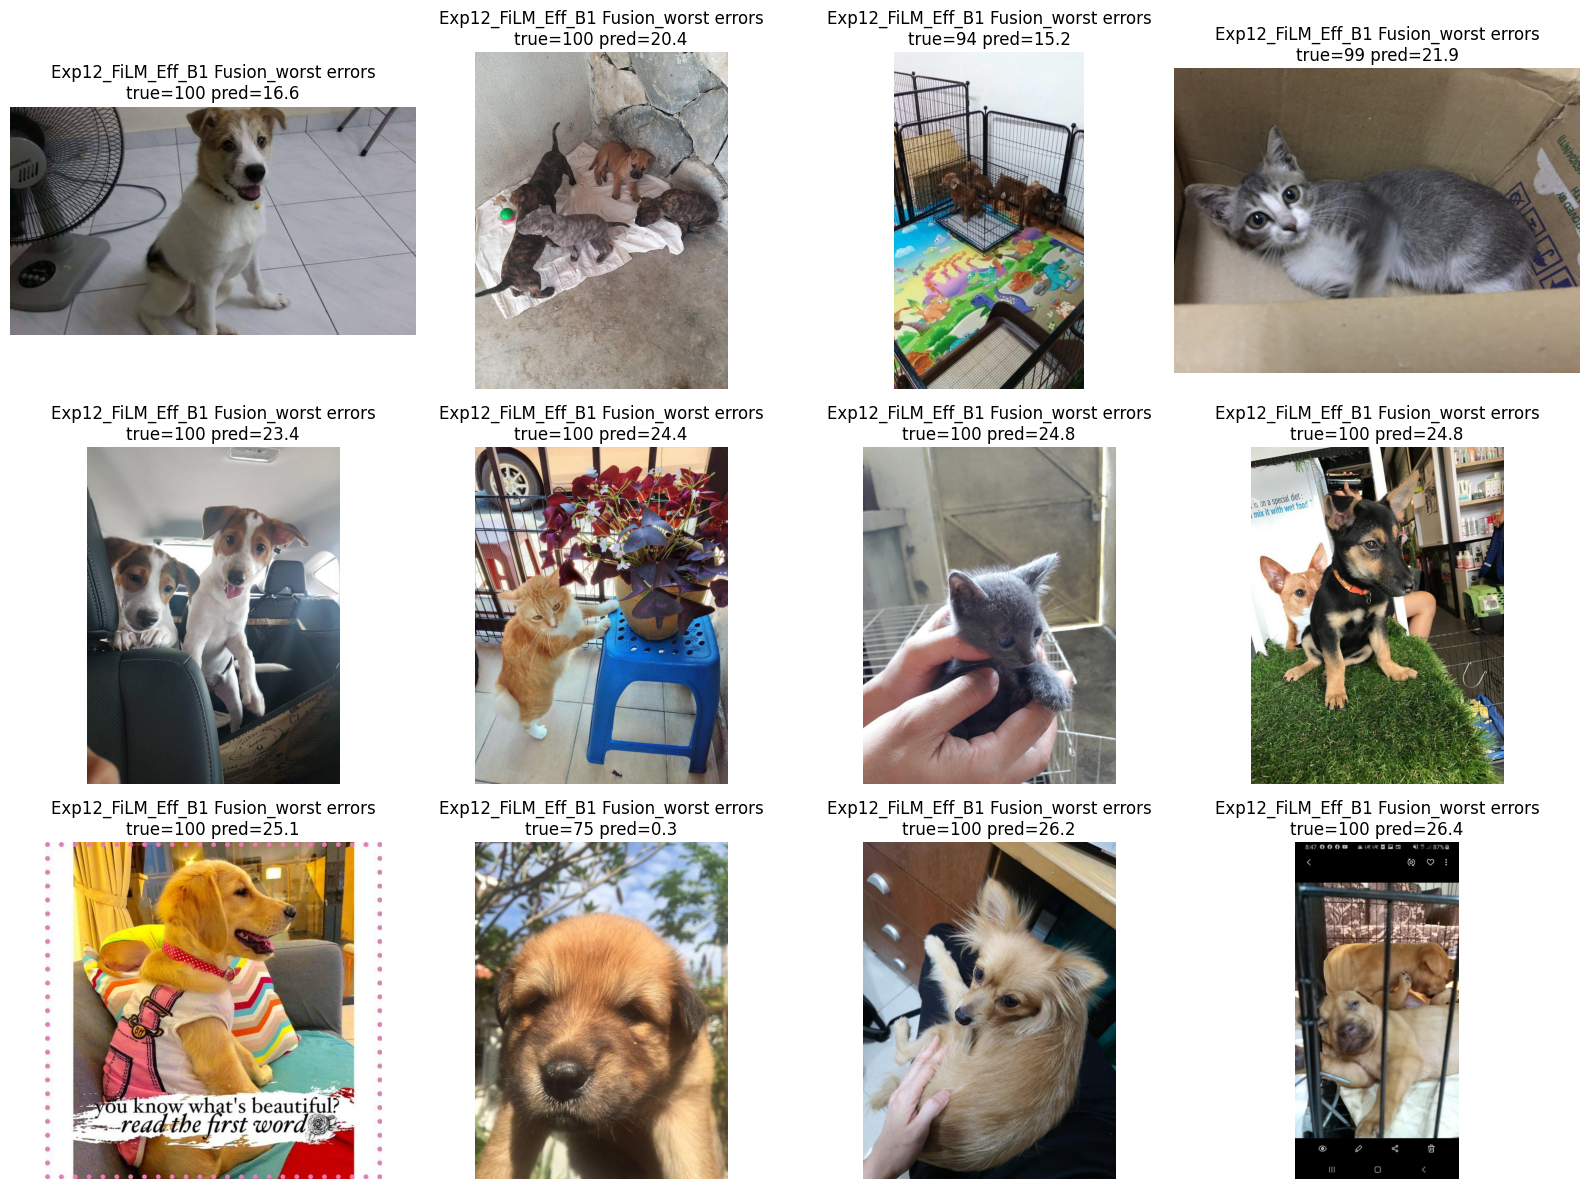

In [15]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12_FiLM_Eff_B1 Fusion_worst errors")

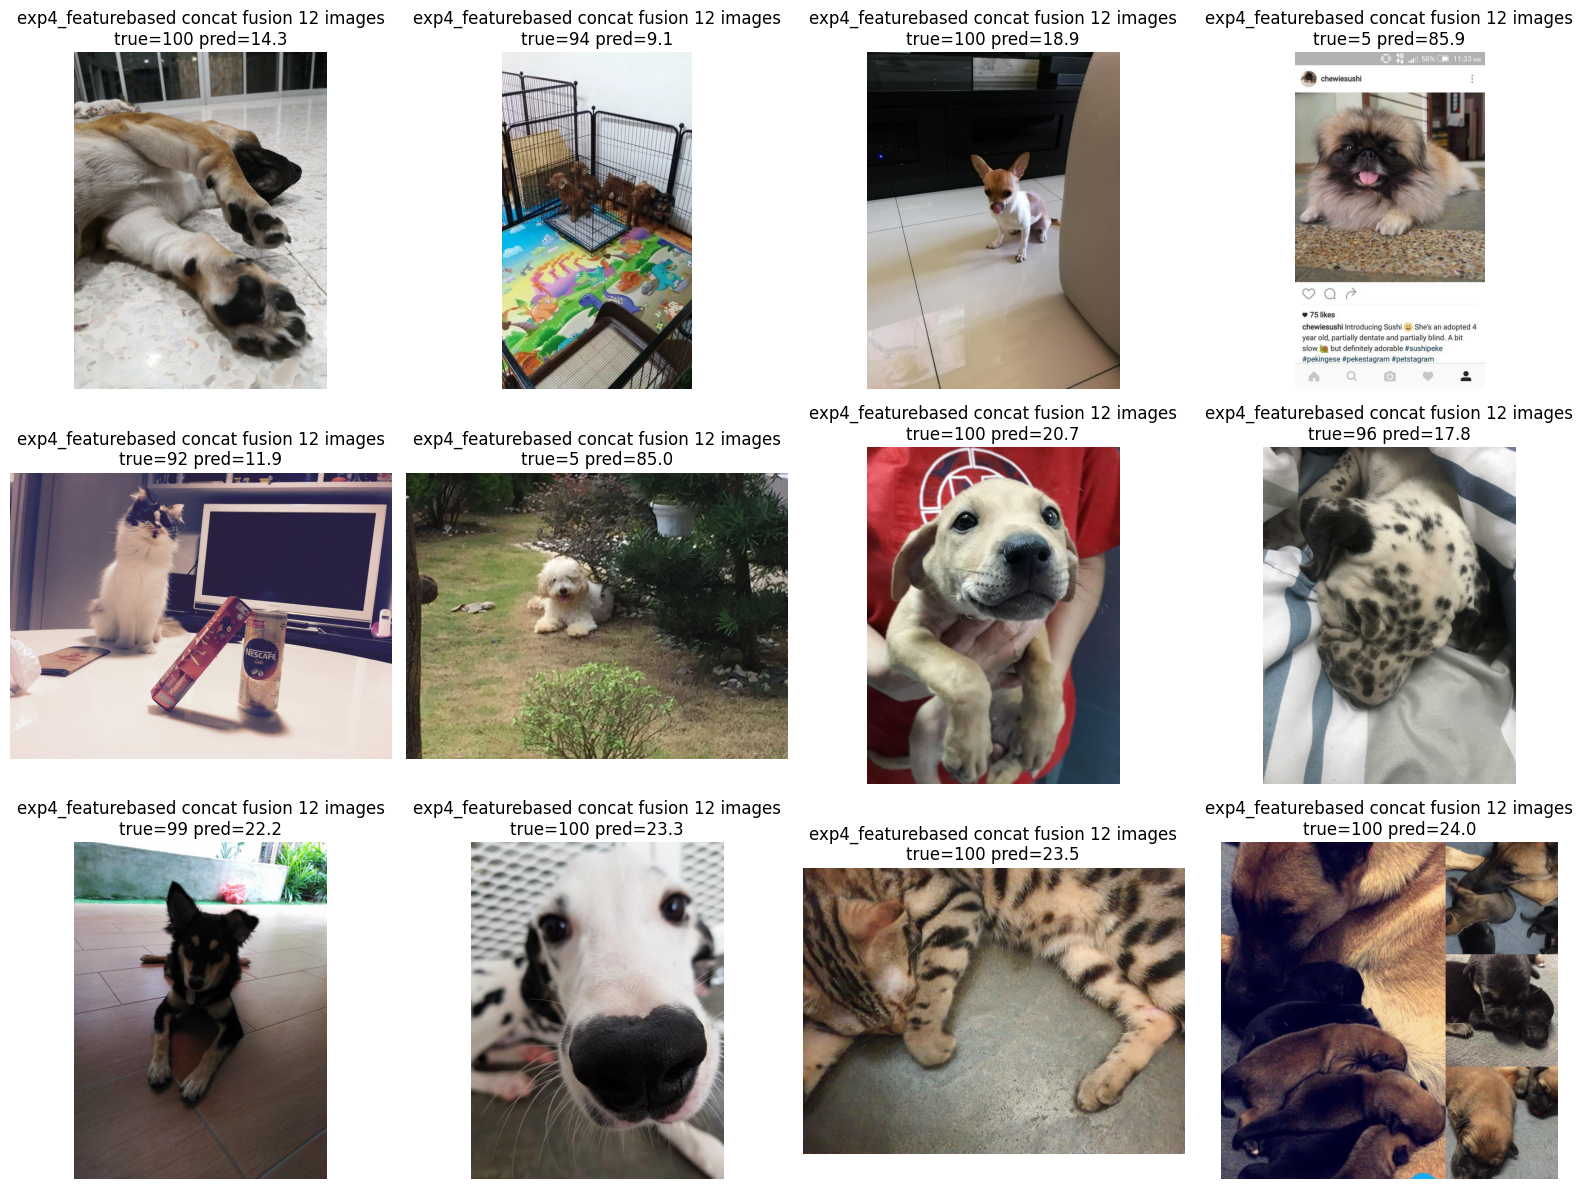

In [16]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")